## Required Libraries

In [1]:
#pip install pandas
#pip install numpy
#pip install matplotlib.pyplot

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

## Imports and Inputs

In [2]:
def load_fracture_data(file_path):
    # Read the file into a pandas DataFrame
    df = pd.read_csv(file_path, delim_whitespace=True, header=None,
                     names=['x_start', 'y_start', 'x_end', 'y_end'])
    # Calculate the length and orientation of each fracture
    df['length'] = np.sqrt((df['x_end'] - df['x_start']) ** 2 + (df['y_end'] - df['y_start']) ** 2)
    df['orientation'] = df.apply(
        lambda row: calculate_orientation(row['x_start'], row['y_start'], row['x_end'], row['y_end']), axis=1)
    return df


In [3]:
# Function to calculate orientation of a line segment
def calculate_orientation(x_start, y_start, x_end, y_end):
    delta_x = x_end - x_start
    delta_y = y_end - y_start
    angle_radians = np.arctan2(delta_x, delta_y)  # Swap delta_x and delta_y
    angle_degrees = np.degrees(angle_radians)
    if angle_degrees < 0:
        angle_degrees += 360
    return angle_degrees

## data visualization

In [4]:
def plot_rose_diagram(df):
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

    # Create bins for the orientations
    bin_edges = np.arange(0, 361, 5)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    df['correctedOrientation'] = df['orientation'].apply(lambda x: x if x <= 180 else x-180)
    # Extend the dataset to include mirrored orientations for full circular distribution
    mirrored_orientation = df['correctedOrientation'] + 180
    extended_orientation = np.concatenate([df['correctedOrientation'], mirrored_orientation])
    ax = plt.subplot(111, polar=True)

    # Create the histogram
    hist, _ = np.histogram(extended_orientation , bins=bin_edges)
    # Plot the histogram
    ax.bar(np.radians(bin_centers), hist, width=np.radians(5), bottom=0.0, alpha=1, color='r')
    ax.set_title('Frequency weighted rose plot')

    # Set the zero direction and the direction of increasing angles
    ax.set_theta_direction(-1)
    ax.set_theta_offset(math.pi/2.0)

    plt.show



In [5]:
df = load_fracture_data('Datasets/Brazil/Apodi.txt')

C:\Users\ekameltarghi\AppData\Local\Temp\ipykernel_1164\3972556871.py:11: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(111, polar=True)


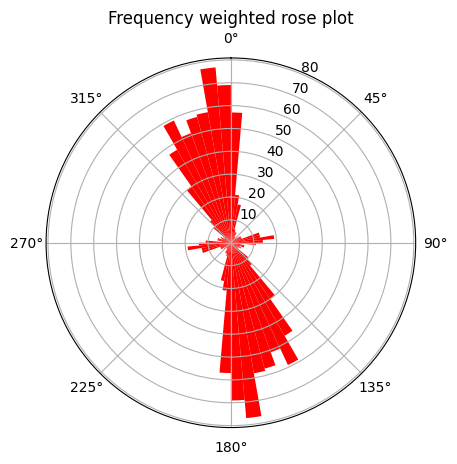

In [6]:
plot_rose_diagram(df)

In [7]:
num_sets=3
range1=[30,120]
range2=[120,175]
range3=[-5,20]

In [8]:
def calculate_set(orientation,range1,range2):
    if ((orientation>=range1[0])  & (orientation<= range1[1])) |  ((orientation>= range1[0]+180) & (orientation <= range1[1]+180)):
        return 1
    elif ((orientation>=range2[0])  & (orientation<= range2[1])) |  ((orientation>= range2[0]+180) & (orientation <= range2[1]+180)):
        return 2
    else:
        return 3

In [9]:
df['set'] = df.apply(
    lambda row: calculate_set(row['orientation'],range1,range2), axis=1)

In [10]:
# Now you can analyze the clusters
print(df.groupby('set')['orientation'].agg(['mean', 'std', 'count']))

           mean        std  count
set                              
1    195.660980  78.980508    126
2    212.309506  82.382486    409
3    180.672397  80.119805    180


In [11]:
def plot_colored_rose_diagram(df, num_sets):
    # Create the directory if it does not exist
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

    # Create bins for the orientations
    bin_edges = np.arange(0, 361,5)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    df['correctedOrientation'] = df['orientation'].apply(lambda x: x if x <= 180 else x-180)
    # Compute the length-weighted orientation histogram for extended orientations
    hist, _ = np.histogram(df['orientation'], bins=bin_edges)

    set_colors =['red', 'blue', 'green', 'purple', 'orange', 'brown']

    # Create the rose diagram
    ax = plt.subplot(111, polar=True)

    # Plot the histogram with colors based on the 'set' column
    for set_number in range(num_sets):
        # Filter the orientations for the current set
        setFractures = df[df['set'] == set_number+1]

        # Extend the dataset to include mirrored orientations for full circular distribution
        mirrored_orientation = setFractures['correctedOrientation'] + 180
        set_orientations = np.concatenate([setFractures['correctedOrientation'], mirrored_orientation])

        # Compute the histogram for the current set
        hist, _ = np.histogram(set_orientations, bins=bin_edges)

        # Plot the bars for the current set
        ax.bar(np.radians(bin_centers), hist, width=np.radians(5), bottom=0.0, alpha=0.5,
               label=f'Set {set_number+1}', color=set_colors[set_number])

    # Set the zero direction and the direction of increasing angles
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    plt.legend(title='Fracture Sets')
    plt.show()

C:\Users\ekameltarghi\AppData\Local\Temp\ipykernel_1164\3741485503.py:15: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(111, polar=True)


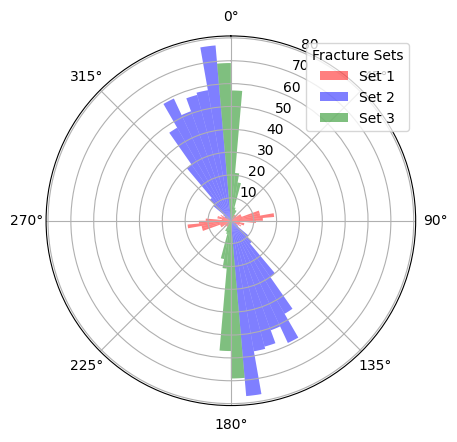

In [12]:
plot_colored_rose_diagram(df,3)

In [13]:
# Visualize the fractures on a scatter plot
def plot_fractures(df,num_sets):
    fig, ax = plt.subplots(figsize=(15, 10)) 
    set_colors =['red', 'blue', 'green', 'purple', 'orange', 'brown']

    # Determine the limits of the plot
    x_min = min(df['x_start'].min(), df['x_end'].min())
    x_max = max(df['x_start'].max(), df['x_end'].max())
    y_min = min(df['y_start'].min(), df['y_end'].min())
    y_max = max(df['y_start'].max(), df['y_end'].max())

    for set_number in range(num_sets):
        # Filter the orientations for the current set
        setFractures = df[df['set'] == set_number+1]
        # Plot each fracture as a line segment
        for idx, row in setFractures.iterrows():
            ax.plot([row['x_start'], row['x_end']], [row['y_start'], row['y_end']],  c=set_colors[set_number], linewidth = 0.5)

    # Set the aspect of the plot to be equal
    ax.set_aspect('equal')

    # Set the plot limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Plot an arrow to indicate North
    ax.annotate('N', xy=(1.03, 1), xytext=(1.03, 0.92),
                arrowprops=dict(facecolor='blue', shrink=0.05),
                ha='center', va='bottom', xycoords='axes fraction', textcoords='axes fraction')

    # Save the plot to a PNG
    plt.show

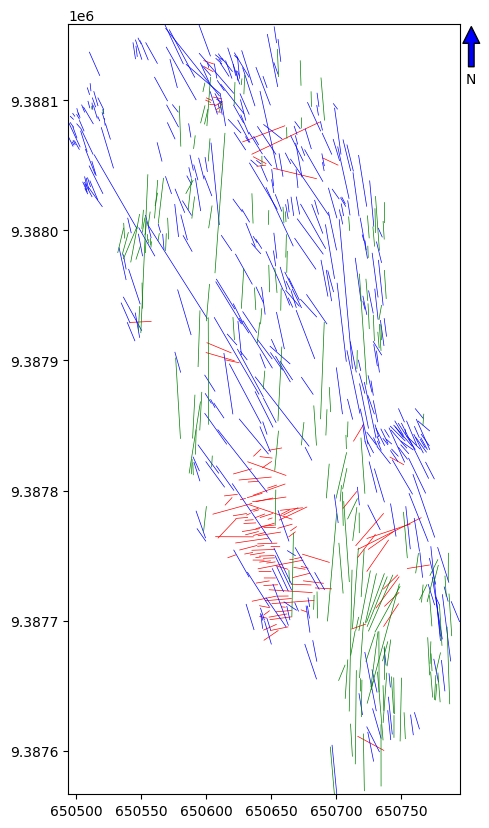

In [14]:
plot_fractures(df,3)

In [15]:
def plot_length_weighted_rose_diagram(df, num_sets):
    # Create the bins for the orientations
    bin_edges = np.arange(0, 361, 5)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Initialize a polar subplot
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    set_colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']

    # Correct the orientations to be between [0, 180)
    df['correctedOrientation'] = df['orientation'].apply(lambda x: x if x <= 180 else x - 180)

    # Calculate length-weighted histogram for each set
    for set_number in range(num_sets):
        # Filter the fractures for the current set
        set_fractures = df[df['set'] == set_number + 1]

        # Compute the length-weighted histogram
        length_hist = np.zeros(len(bin_centers))
        
        for i in range(len(bin_centers)):
            # Find fractures that fall into the current bin
            in_bin = (set_fractures['correctedOrientation'] >= bin_edges[i]) & (set_fractures['correctedOrientation'] < bin_edges[i+1])
            # Sum the lengths of fractures in the bin
            length_hist[i] = set_fractures[in_bin]['length'].sum()

        # Mirror the histogram for full circular representation
        mirrored_hist = np.concatenate([length_hist, length_hist])

        # Plot the bars for the current set
        ax.bar(np.radians(np.concatenate([bin_centers, bin_centers + 180])), mirrored_hist, 
               width=np.radians(5), bottom=0.0, alpha=0.5, label=f'Set {set_number+1}', 
               color=set_colors[set_number % len(set_colors)])

    # Set the zero direction (North) and the direction of increasing angles (clockwise)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # Add a legend and show the plot
    plt.legend(title='Fracture Sets')
    plt.show()

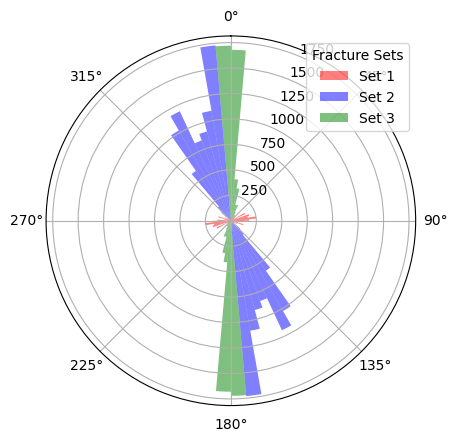

In [16]:
plot_length_weighted_rose_diagram(df,3)

## Calculate required inputs

This network has 3 fracture sets which their rientation was defined before

### Domain Size

In [17]:
def calculate_domain_size(df):
    x_min = min(df['x_start'].min(), df['x_end'].min())
    x_max = max(df['x_start'].max(), df['x_end'].max())
    y_min = min(df['y_start'].min(), df['y_end'].min())
    y_max = max(df['y_start'].max(), df['y_end'].max())

    domain_width = x_max - x_min
    domain_height = y_max - y_min

    return domain_width, domain_height

In [18]:
domainX,domainY=calculate_domain_size(df)

In [19]:
print(domainX,domainY)

300.7399999999907 591.9199999999255


### Intensity

In [20]:
def calculate_p21_by_set(df, domainX, domainY):
    # Group by the 'set' column
    grouped = df.groupby('set')
    # Calculate P21 for each set
    p21_by_set = grouped['length'].sum() / (domainX * domainY)
    return p21_by_set

In [21]:
calculate_p21_by_set(df, domainX, domainY)

set
1    0.009972
2    0.043530
3    0.025600
Name: length, dtype: float64

In [143]:
0.009972+0.043530+0.025600

0.079102

### Length Disturbution

In [22]:
import scipy.stats as stats

In [24]:
def plot_length_distribution(df, num_sets):
    # Initialize the list to store best fit properties for each set
    length_best_fit_properties = []
    fig, axs = plt.subplots(1, num_sets, figsize=(15, 5), sharey=True)
    num_bins = 50  # Or choose a number that suits your data
    set_colors = ['red', 'blue', 'green']

    # Define a function to compute the sum of squared errors
    def sse(y_observed, y_expected):
        return np.sum((y_observed - y_expected) ** 2)

    for i in range(num_sets):
        current_set = df[df['set'] == i + 1]
        lengths = current_set['length']

        # Histogram values (density=True to normalize the histogram)
        hist_vals, bin_edges = np.histogram(lengths, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Distributions updated to include parameter extraction
        distributions = {
            'uniform': {
                'func': lambda x: np.ones_like(x) * (1.0 / (max(lengths) - min(lengths))),
                'params': lambda: {'dmin': min(lengths), 'dmax': max(lengths)}
            },
            'constant': {
                'func': lambda x: np.mean(lengths),
                'params': lambda: {'L': np.mean(lengths)}
            },
            'lognormal': {
                'func': lambda x: stats.lognorm.pdf(x, *stats.lognorm.fit(lengths)),
                'params': lambda: {'mu':np.log(stats.lognorm.fit(lengths)[2]), 'sigma': stats.lognorm.fit(lengths)[0], 'Lmin': min(lengths), 'Lmax': max(lengths)}
            },
            'exponential': {
                'func': lambda x: stats.expon.pdf(x, *stats.expon.fit(lengths)),
                'params': lambda: {'lambda': 1/stats.expon.fit(lengths)[1], 'Lmin': min(lengths), 'Lmax': max(lengths)}
            },
            # Add power law fitting here, assuming a simplified approach
            'power law': {
                'func': lambda x: stats.powerlaw.pdf(x, *stats.powerlaw.fit(lengths)),
                'params': lambda: {'alpha': stats.powerlaw.fit(lengths)[0], 'Lmin': min(lengths), 'Lmax': max(lengths)}
            }
        }
        # Calculate SSE and store best fitting parameters
        sse_values = {}
        for name, dist in distributions.items():
            try:
                y_expected = dist['func'](bin_centers)
                sse_values[name] = sse(hist_vals, y_expected)
            except Exception as e:
                print(f"Could not fit {name} distribution due to: {e}")

        # Find the best distribution based on SSE and retrieve its parameters
        best_fit = min(sse_values, key=sse_values.get)
        best_fit_params = distributions[best_fit]['params']()

        # Add best fit parameters for the current set to the list
        length_best_fit_properties.append({'set': i + 1, 'distribution': best_fit, **best_fit_params})

        # Plot the histogram
        axs[i].hist(lengths, bins=num_bins, color=set_colors[i], alpha=0.6, density=True)

        # Plot the best-fitted distribution
        y_best_fit = distributions[best_fit]['func'](bin_centers)
        axs[i].plot(bin_centers, y_best_fit, 'k-', linewidth=2)  # 'k-' for black line

        # Set the title for the subplot and labels
        title = f'Set {i + 1} - Best fit: {best_fit}'
        axs[i].set_title(title)
        axs[i].set_xlabel('Length')
        
        if i == 0:
            axs[i].set_ylabel('Density')

    plt.tight_layout()
    plt.show()
    # Convert list to DataFrame
    length_df_best_fit = pd.DataFrame(length_best_fit_properties)
    
    # Display the DataFrame
    print(length_df_best_fit)


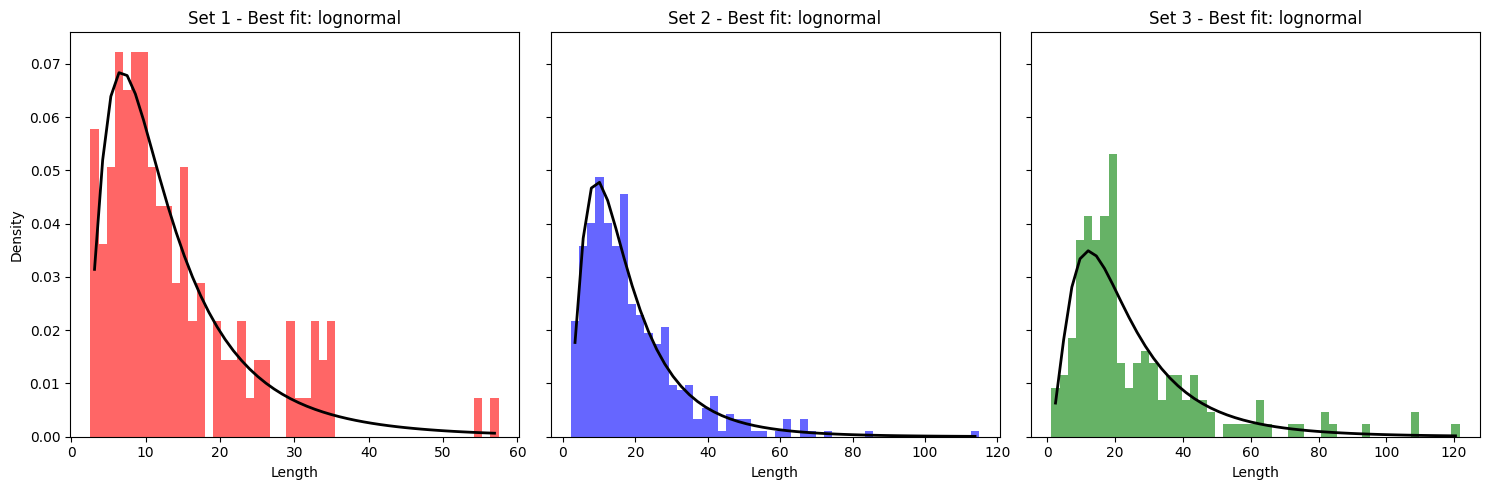

   set distribution        mu     sigma      Lmin        Lmax
0    1    lognormal  2.344017  0.726376  2.588165   57.475349
1    2    lognormal  2.732562  0.680523  2.228004  114.918234
2    3    lognormal  3.061682  0.669114  1.203329  121.619054


In [25]:
plot_length_distribution(df, 3)

### Orientation Disturbution

In [26]:
from scipy.stats import vonmises

set=1, Kappa= 8.554380346458608 loc= 1.397789299090116


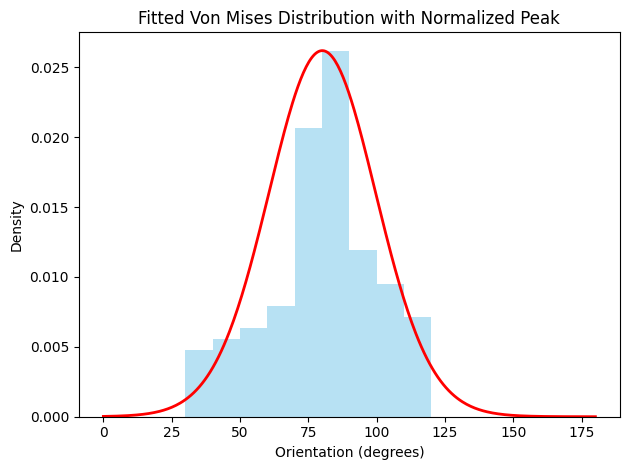

In [27]:
current_set = df[df['set'] == 1].copy()  # Use copy to avoid SettingWithCopyWarning
current_set['correctedOrientation'] = current_set['orientation'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=1, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak')

# Show the plot
plt.tight_layout()
plt.show()

set=2, Kappa= 24.49432280926717 loc= 2.753794563263896


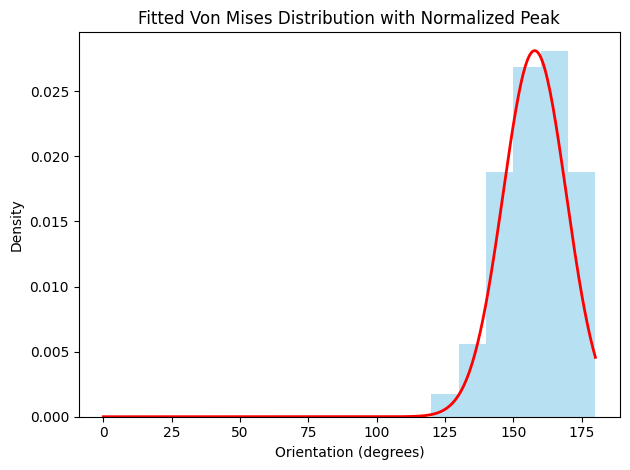

In [28]:
current_set = df[df['set'] == 2].copy()  # Use copy to avoid SettingWithCopyWarning
current_set['correctedOrientation'] = current_set['orientation'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=2, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak')

# Show the plot
plt.tight_layout()
plt.show()

In [29]:
#this is just for set 3 that has orintation around 0, whichi makes it difficult ot fit disturbution considering circularity of the data
def calculate_corrected_orientations(orientation):
    if 270<orientation<=360 :
        return orientation-360
    elif 180<orientation<=270:
        return orientation-180
    elif 90<orientation<=180:
        return -(180-orientation)
    else:
        return orientation

set=3, Kappa= 58.161665860907675 loc= 0.06360677859064885


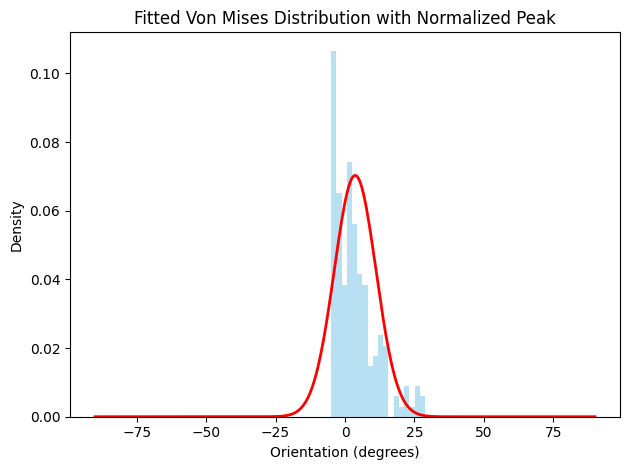

In [30]:
current_set = df[df['set'] == 3].copy()  # Use copy to avoid SettingWithCopyWarning
current_set['correctedOrientation'] = current_set['orientation'] .apply(lambda x: calculate_corrected_orientations(x))
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=3, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(-90, 90, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak')

# Show the plot
plt.tight_layout()
plt.show()

### spatial disturbution

In [23]:
from scipy.spatial import distance_matrix

In [24]:
def calculate_spatial_distances_per_set(df):
    """
    Calculate all Euclidean distances between points within each set.
    """
    distances_dict = {}

    sets = df['set'].unique()

    for set_id in sets:
        set_df = df[df['set'] == set_id]
        points = np.vstack((set_df[['x_start', 'y_start']].values, set_df[['x_end', 'y_end']].values))

        dist_matrix = distance_matrix(points, points)

        # Flatten the distance matrix and exclude zeros (distance to itself)
        distances = dist_matrix[dist_matrix != 0]

        distances_dict[set_id] = distances

    return distances_dict

In [25]:
spatial_distances=calculate_spatial_distances_per_set(df)

In [98]:

def plot_spatial_distribution(df, num_sets, spatial_distances, sample_fraction=0.1):
    spatial_best_fit_properties = []
    fig, axs = plt.subplots(1, num_sets, figsize=(num_sets*5, 5), sharey=True)
    num_bins = 200  # Adjust based on your data
    set_colors = ['red', 'blue', 'green']

    def sse(y_observed, y_expected):
        return np.sum((y_observed - y_expected) ** 2)

    for i, set_id in enumerate(sorted(spatial_distances.keys())):
        # Access the full set of distances
        full_set_distances = spatial_distances[set_id]
        
        # Determine the number of samples to draw, based on the specified fraction
        sample_size = int(len(full_set_distances) * sample_fraction)
        
        # If the sample size is larger than the array, use the full array
        if sample_size < 1:
            print(f"Sample size for set {set_id} is less than 1. Using the full dataset.")
            sample_size = len(full_set_distances)
        
        # Randomly sample the distances
        if len(full_set_distances) > sample_size:
            sampled_indices = np.random.choice(len(full_set_distances), size=sample_size, replace=False)
            current_set_distances = full_set_distances[sampled_indices]
        else:
            current_set_distances = full_set_distances
        

        hist_vals, bin_edges = np.histogram(current_set_distances, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Distributions updated to include parameter extraction
        distributions = {
            'uniform': {
                'func': lambda x: np.ones_like(x) * (1.0 / (max(current_set_distances) - min(current_set_distances))),
                'params': lambda: {'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            'constant': {
                'func': lambda x: np.ones_like(x) * np.mean(current_set_distances),
                'params': lambda: {'L': np.mean(current_set_distances)}
            },
            
            'lognormal': {
                'func': lambda x: stats.lognorm.pdf(x, *stats.lognorm.fit(current_set_distances)),
                'params': lambda: {'mu': np.log(stats.lognorm.fit(current_set_distances)[2]), 'sigma': stats.lognorm.fit(current_set_distances)[0], 'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            # Add power law fitting here, assuming a simplified approach
            'power law': {
                'func': lambda x: stats.powerlaw.pdf(x, *stats.powerlaw.fit(current_set_distances)),
                'params': lambda: {'alpha': stats.powerlaw.fit(current_set_distances)[0],'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            }
        }
        # Calculate SSE and store best fitting parameters
        sse_values = {}
        for name, dist in distributions.items():
            try:
                y_expected = dist['func'](bin_centers)
                sse_values[name] = sse(hist_vals, y_expected)
            except Exception as e:
                print(f"Could not fit {name} distribution due to: {e}")

        # Find the best distribution based on SSE and retrieve its parameters
        best_fit = min(sse_values, key=sse_values.get)
        best_fit_params = distributions[best_fit]['params']()

        # Add best fit parameters for the current set to the list
        spatial_best_fit_properties.append({'set': i + 1, 'distribution': best_fit, **best_fit_params})

        # Plot the histogram
        axs[i].hist(current_set_distances, bins=num_bins, color=set_colors[i], alpha=0.6, density=True)

        # Plot the best-fitted distribution
        y_best_fit = distributions[best_fit]['func'](bin_centers)
        axs[i].plot(bin_centers, y_best_fit, 'k-', linewidth=2)  # 'k-' for black line

        # Set the title for the subplot and labels
        title = f'Set {i + 1} - Best fit: {best_fit}'
        axs[i].set_title(title)
        axs[i].set_xlabel('Distance')
        axs[i].axhline(y=0.001, color='gray', linestyle='--', linewidth=1)
        
        if i == 0:
            axs[i].set_ylabel('Density')

    # Convert list to DataFrame and display
    length_df_best_fit = pd.DataFrame(spatial_best_fit_properties)
    print(length_df_best_fit)

    plt.tight_layout()
    plt.show()

   set distribution     alpha      dmin        dmax
0    1    power law  0.514483  0.671863  543.562576
1    2    power law  0.731000  0.370000  602.883801
2    3    power law  0.808608  1.072986  561.068333


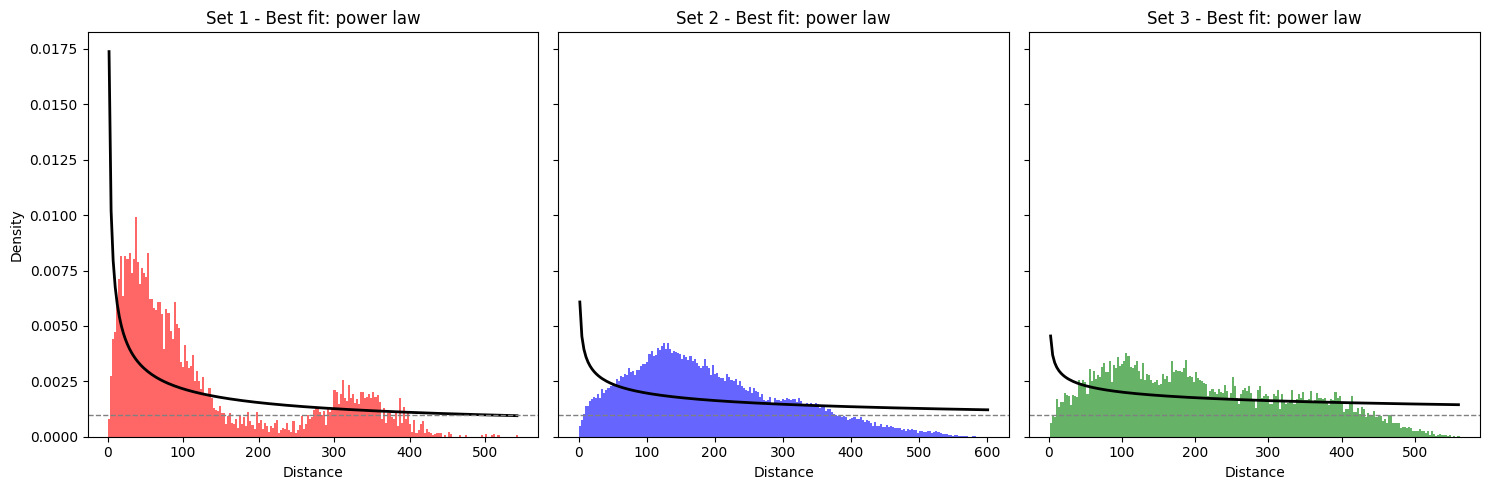

In [99]:
plot_spatial_distribution(df, num_sets, spatial_distances)

In [96]:
from scipy.stats import gaussian_kde
# Define the power law function
def negativePowerLaw(alpha, min_val=2, max_val=1000):
    if max_val is None:
        max_val = np.inf
    cdf_min = 1 - min_val ** (-alpha + 1)
    cdf_max = 1 - max_val ** (-alpha + 1)
    u = np.random.rand() * (cdf_max - cdf_min) + cdf_min
    val = min_val / (1 - u) ** (1 / (alpha - 1))
    max_attempts = 1000
    attempts = 0
    while val > max_val and attempts < max_attempts:
        u = np.random.rand() * (cdf_max - cdf_min) + cdf_min
        val = min_val / (1 - u) ** (1 / (alpha - 1))
        attempts += 1
    if attempts >= max_attempts:
        raise ValueError("Unable to generate a value within the specified range after many attempts.")
    return val

def plot_spatial_distribution(df, num_sets, spatial_distances, sample_fraction=0.1):
    spatial_best_fit_properties = []
    fig, axs = plt.subplots(1, num_sets, figsize=(num_sets*5, 5), sharey=True)
    num_bins = 200  # Adjust based on your data
    set_colors = ['red', 'blue', 'green']

    def sse(y_observed, y_expected):
        return np.sum((y_observed - y_expected) ** 2)

    for i, set_id in enumerate(sorted(spatial_distances.keys())):
        # Access the full set of distances
        full_set_distances = spatial_distances[set_id]
        
        # Determine the number of samples to draw, based on the specified fraction
        sample_size = int(len(full_set_distances) * sample_fraction)
        
        # If the sample size is larger than the array, use the full array
        if sample_size < 1:
            print(f"Sample size for set {set_id} is less than 1. Using the full dataset.")
            sample_size = len(full_set_distances)
        
        # Randomly sample the distances
        if len(full_set_distances) > sample_size:
            sampled_indices = np.random.choice(len(full_set_distances), size=sample_size, replace=False)
            current_set_distances = full_set_distances[sampled_indices]
        else:
            current_set_distances = full_set_distances
        

        hist_vals, bin_edges = np.histogram(current_set_distances, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Distributions updated to include parameter extraction
        distributions = {
            'uniform': {
                'func': lambda x: np.ones_like(x) * (1.0 / (max(current_set_distances) - min(current_set_distances))),
                'params': lambda: {'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            'constant': {
                'func': lambda x: np.ones_like(x) * np.mean(current_set_distances),
                'params': lambda: {'L': np.mean(current_set_distances)}
            },
            
            'lognormal': {
                'func': lambda x: stats.lognorm.pdf(x, *stats.lognorm.fit(current_set_distances)),
                'params': lambda: {'mu': np.log(stats.lognorm.fit(current_set_distances)[2]), 'sigma': stats.lognorm.fit(current_set_distances)[0], 'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            # Add power law fitting here, assuming a simplified approach
            'power law': {
                'func': lambda x: stats.powerlaw.pdf(x, *stats.powerlaw.fit(current_set_distances)),
                'params': lambda: {'alpha': stats.powerlaw.fit(current_set_distances)[0],'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            }
        }
        # Calculate SSE and store best fitting parameters
        sse_values = {}
        for name, dist in distributions.items():
            try:
                y_expected = dist['func'](bin_centers)
                sse_values[name] = sse(hist_vals, y_expected)
            except Exception as e:
                print(f"Could not fit {name} distribution due to: {e}")

        # Find the best distribution based on SSE and retrieve its parameters
        best_fit = min(sse_values, key=sse_values.get)
        best_fit_params = distributions[best_fit]['params']()

        # Add best fit parameters for the current set to the list
        spatial_best_fit_properties.append({'set': i + 1, 'distribution': best_fit, **best_fit_params})

        # Plot the histogram
        axs[i].hist(current_set_distances, bins=num_bins, color=set_colors[i], alpha=0.6, density=True)

        # Plot the best-fitted distribution
        samples=1000
        alpha=best_fit_params['alpha']
        min_val=best_fit_params['dmin']
        max_val=best_fit_params['dmax']
        values = [negativePowerLaw(alpha, min_val, max_val) for _ in range(samples)]
        kde = gaussian_kde(values, bw_method=0.3)  # Kernel density estimation for smooth curve
        x = np.linspace(min_val, max_val, 1000)  # Set the range for x-axis
        axs[i].plot(x, kde(x), label=f'alpha={alpha}')
    
    
    
        #y_best_fit = distributions[best_fit]['func'](bin_centers)
        #axs[i].plot(bin_centers, y_best_fit, 'k-', linewidth=2)  # 'k-' for black line

        # Set the title for the subplot and labels
        title = f'Set {i + 1} - Best fit: {best_fit}'
        axs[i].set_title(title)
        axs[i].set_xlabel('Distance')
        axs[i].axhline(y=0.001, color='gray', linestyle='--', linewidth=1)
        
        if i == 0:
            axs[i].set_ylabel('Density')

    # Convert list to DataFrame and display
    length_df_best_fit = pd.DataFrame(spatial_best_fit_properties)
    print(length_df_best_fit)

    plt.tight_layout()
    plt.show()

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def plot_spatial_distribution(df, num_sets, spatial_distances):
    spatial_best_fit_properties = []
    fig, axs = plt.subplots(1, num_sets, figsize=(num_sets*5, 5), sharey=True)
    num_bins = 50  # Adjust based on your data
    set_colors = ['red', 'blue', 'green']

    def sse(y_observed, y_expected):
        return np.sum((y_observed - y_expected) ** 2)

    for i, set_id in enumerate(sorted(spatial_distances.keys())):
        # Access the full set of distances
        full_set_distances = spatial_distances[set_id]
        full_set_distances=full_set_distances[full_set_distances>3.5]

        current_set_distances = full_set_distances
        
        hist_vals, bin_edges = np.histogram(current_set_distances, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Define the distributions
        distributions = {
            'uniform': {
                'func': lambda x: np.ones_like(x) * (1.0 / (max(current_set_distances) - min(current_set_distances))),
                'params': lambda: {'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            'constant': {
                'func': lambda x: np.ones_like(x) * np.mean(current_set_distances),
                'params': lambda: {'L': np.mean(current_set_distances)}
            },
            'lognormal': {
                'func': lambda x: stats.lognorm.pdf(x, *stats.lognorm.fit(current_set_distances)),
                'params': lambda: {'mu': np.log(stats.lognorm.fit(current_set_distances)[2]), 'sigma': stats.lognorm.fit(current_set_distances)[0], 'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            'power law': {
                'func': lambda x: stats.powerlaw.pdf(x, *stats.powerlaw.fit(current_set_distances)),
                'params': lambda: {'alpha': stats.powerlaw.fit(current_set_distances)[0], 'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            }
        }

        # Calculate SSE and store best fitting parameters
        sse_values = {}
        for name, dist in distributions.items():
            try:
                y_expected = dist['func'](bin_centers)
                sse_values[name] = sse(hist_vals, y_expected)
            except Exception as e:
                print(f"Could not fit {name} distribution due to: {e}")

        # Find the best distribution based on SSE and retrieve its parameters
        best_fit = min(sse_values, key=sse_values.get)
        best_fit_params = distributions[best_fit]['params']()

        # Add best fit parameters for the current set to the list
        spatial_best_fit_properties.append({'set': i + 1, 'distribution': best_fit, **best_fit_params})

        # Plot the histogram
        axs[i].hist(current_set_distances, bins=num_bins, color=set_colors[i], alpha=0.6, density=True)

        # Plot the best-fitted distribution
        y_best_fit = distributions[best_fit]['func'](bin_centers[bin_centers>3.5])
        axs[i].plot(bin_centers[bin_centers>3.5], y_best_fit, 'k-', linewidth=2, label=f'Best fit: {best_fit}')  # 'k-' for black line

        # Set the title for the subplot and labels
        title = f'Set {i + 1} - Best fit: {best_fit}'
        axs[i].set_title(title)
        axs[i].set_xlabel('Distance')
        axs[i].axhline(y=0.001, color='gray', linestyle='--', linewidth=1)
        axs[i].set_ylim([0,0.01])

        if i == 0:
            axs[i].set_ylabel('Density')
        axs[i].legend()

    # Convert list to DataFrame and display
    length_df_best_fit = pd.DataFrame(spatial_best_fit_properties)
    print(length_df_best_fit)

    plt.tight_layout()
    plt.show()


   set distribution     alpha      dmin        dmax
0    1    power law  0.500995  3.500529  548.060534
1    2    power law  0.717342  3.503042  606.137850
2    3    power law  0.773221  3.567366  574.337925


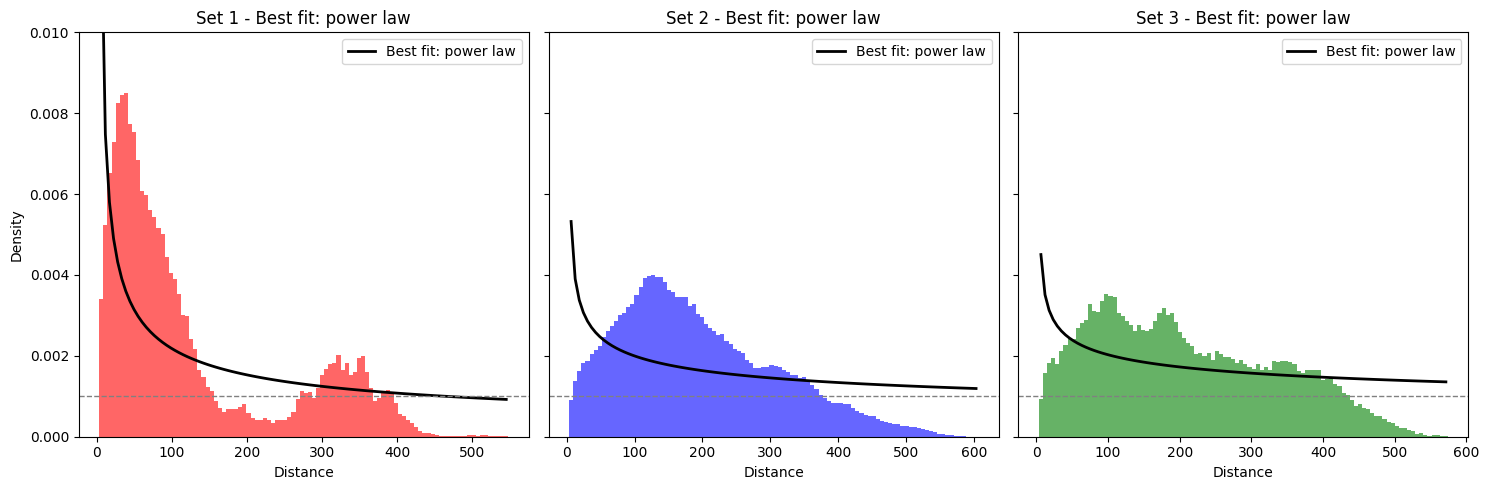

In [140]:
plot_spatial_distribution(df, num_sets, spatial_distances)

   set distribution     alpha      dmin        dmax
0    1    power law  0.500995  3.500529  548.060534
1    2    power law  0.717342  3.503042  606.137850
2    3    power law  0.773221  3.567366  574.337925


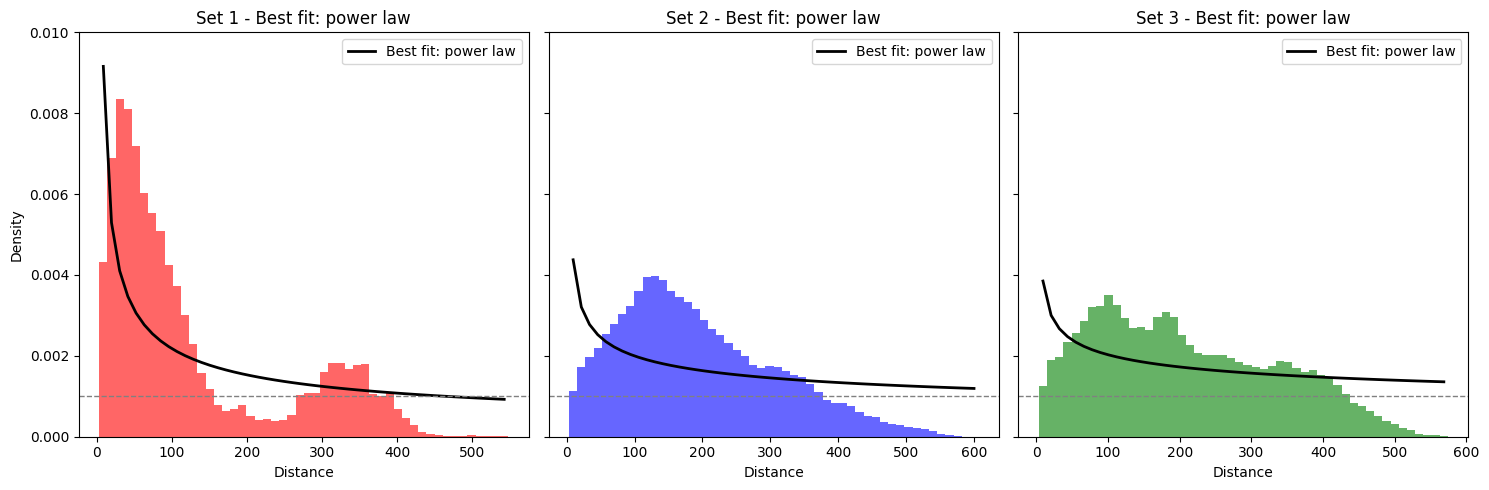

In [142]:
plot_spatial_distribution(df, num_sets, spatial_distances)

In [115]:
def plot_spatial_distribution(df, num_sets, spatial_distances, sample_fraction=0.8):
    spatial_best_fit_properties = []
    fig, axs = plt.subplots(1, num_sets, figsize=(num_sets*5, 5), sharey=True)
    num_bins = 200  # Adjust based on your data
    set_colors = ['red', 'blue', 'green']

    def sse(y_observed, y_expected):
        return np.sum((y_observed - y_expected) ** 2)

    for i, set_id in enumerate(sorted(spatial_distances.keys())):
        # Access the full set of distances
        full_set_distances = spatial_distances[set_id]
        
        # Determine the number of samples to draw, based on the specified fraction
        sample_size = int(len(full_set_distances) * sample_fraction)
        
        # If the sample size is larger than the array, use the full array
        if sample_size < 1:
            print(f"Sample size for set {set_id} is less than 1. Using the full dataset.")
            sample_size = len(full_set_distances)
        
        # Randomly sample the distances
        if len(full_set_distances) > sample_size:
            sampled_indices = np.random.choice(len(full_set_distances), size=sample_size, replace=False)
            current_set_distances = full_set_distances[sampled_indices]
        else:
            current_set_distances = full_set_distances
        

        hist_vals, bin_edges = np.histogram(current_set_distances, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Distributions updated to include parameter extraction
        distributions = {
            #'uniform': {
            #    'func': lambda x: np.ones_like(x) * (1.0 / (max(current_set_distances) - min(current_set_distances))),
            #    'params': lambda: {'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            #},
            #'constant': {
            #    'func': lambda x: np.ones_like(x) * np.mean(current_set_distances),
            #    'params': lambda: {'L': np.mean(current_set_distances)}
            #},
            
            'lognormal': {
                'func': lambda x: stats.lognorm.pdf(x, *stats.lognorm.fit(current_set_distances)),
                'params': lambda: {'mu': np.log(stats.lognorm.fit(current_set_distances)[2]), 'sigma': stats.lognorm.fit(current_set_distances)[0], 'dmin': min(current_set_distances), 'dmax': max(current_set_distances)}
            },
            # Add power law fitting here, assuming a simplified approach
                        # Power law fitting that starts with checking if exponent > 1
            'power law': {
                'func': lambda x: stats.powerlaw.pdf(x, *power_law_fit_safe(current_set_distances)),
                'params': lambda: power_law_fit_safe(current_set_distances)
            }
        }
        # Calculate SSE and store best fitting parameters
        sse_values = {}
        for name, dist in distributions.items():
            try:
                y_expected = dist['func'](bin_centers)
                sse_values[name] = sse(hist_vals, y_expected)
            except Exception as e:
                print(f"Could not fit {name} distribution due to: {e}")

        # Find the best distribution based on SSE and retrieve its parameters
        best_fit = min(sse_values, key=sse_values.get)
        best_fit_params = distributions[best_fit]['params']()

        if best_fit_params is None:
            print(f"Invalid power law fit for set {i+1}. Moving to the next best distribution.")
            # You could also choose to skip this set or take further actions here
            continue  # Skip this iteration if the best fit is not valid

        # Add best fit parameters for the current set to the list
        spatial_best_fit_properties.append({'set': i + 1, 'distribution': best_fit, **best_fit_params})

        # Plot the histogram
        axs[i].hist(current_set_distances, bins=num_bins, color=set_colors[i], alpha=0.6, density=True)

        # Plot the best-fitted distribution
        print(best_fit)
        y_best_fit = distributions[best_fit]['func'](bin_centers)
        axs[i].plot(bin_centers, y_best_fit, 'k-', linewidth=2)  # 'k-' for black line

        # Set the title for the subplot and labels
        title = f'Set {i + 1} - Best fit: {best_fit}'
        axs[i].set_title(title)
        axs[i].set_xlabel('Distance')
        axs[i].axhline(y=0.001, color='gray', linestyle='--', linewidth=1)
        
        if i == 0:
            axs[i].set_ylabel('Density')

    # Convert list to DataFrame and display
    length_df_best_fit = pd.DataFrame(spatial_best_fit_properties)
    print(length_df_best_fit)

    plt.tight_layout()
    plt.show()

In [50]:
best_fit

NameError: name 'best_fit' is not defined

### Spacing

In [36]:
def calculate_line_distance(point, line_start, line_end):
    """Calculate minimum distance from a point to a line segment."""
    line_vec = line_end - line_start
    point_vec = point - line_start
    line_len = np.linalg.norm(line_vec)
    line_unitvec = line_vec / line_len
    point_vec_scaled = point_vec / line_len
    t = np.dot(line_unitvec, point_vec_scaled)
    if t < 0.0:
        t = 0.0
    elif t > 1.0:
        t = 1.0
    nearest = line_vec * t
    dist = np.linalg.norm(point_vec - nearest)
    return dist
def calculate_perpendicular_distance(line1_start, line1_end, line2_start, line2_end):
    """Calculate perpendicular distances and return the minimum."""
    distances = []
    distances.append(calculate_line_distance(line1_start, line2_start, line2_end))
    distances.append(calculate_line_distance(line1_end, line2_start, line2_end))
    distances.append(calculate_line_distance(line2_start, line1_start, line1_end))
    distances.append(calculate_line_distance(line2_end, line1_start, line1_end))
    return min(distances)

def remove_high_value_outliers(spacings, percentile=99):
    """Remove high-value outliers based on a specified percentile cutoff."""
    cutoff = np.percentile(spacings, percentile)
    return spacings[spacings <= cutoff]

def calculate_spacing_with_high_value_outlier_removal(df, percentile=99):
    """Calculate minimum normal distance between line segments within each set with high-value outlier removal."""
    sets = df['set'].unique()
    spacing_results = []

    for set_id in sets:
        set_df = df[df['set'] == set_id].copy()
        num_fractures = len(set_df)
        min_distances = np.full(num_fractures, np.inf)

        # Calculate distances
        for i in range(num_fractures):
            for j in range(i + 1, num_fractures):
                line1_start = np.array([set_df.iloc[i]['x_start'], set_df.iloc[i]['y_start']])
                line1_end = np.array([set_df.iloc[i]['x_end'], set_df.iloc[i]['y_end']])
                line2_start = np.array([set_df.iloc[j]['x_start'], set_df.iloc[j]['y_start']])
                line2_end = np.array([set_df.iloc[j]['x_end'], set_df.iloc[j]['y_end']])

                distance = calculate_perpendicular_distance(line1_start, line1_end, line2_start, line2_end)
                min_distances[i] = min(min_distances[i], distance)
                min_distances[j] = min(min_distances[j], distance)

        # Determine which distances are below the percentile cutoff and are not zero
        cutoff = np.percentile(min_distances, percentile)
        valid_distances_indices = (min_distances <= cutoff) & (min_distances > 0.01)

        
        # Assign spacings for distances below the cutoff, others get NaN
        set_df['spacing'] = np.where(valid_distances_indices, min_distances, np.nan)
        spacing_results.append(set_df)

    # Combine all sets back into a single DataFrame with high-value outliers removed
    results_df = pd.concat(spacing_results, ignore_index=True)
    # Calculate mean spacing for each set, ignoring NaNs
    spacing_df = results_df.groupby('set').agg(mean_spacing=('spacing', 'mean')).reset_index()
    spacing_df['bufferZone'] = spacing_df['mean_spacing'] / 2
    
    return spacing_df,results_df


In [37]:
spacing_df,results_df=calculate_spacing_with_high_value_outlier_removal(df)

In [38]:
print(spacing_df)

   set  mean_spacing  bufferZone
0    1      2.804550    1.402275
1    2      1.586353    0.793177
2    3      3.330149    1.665075


In [39]:
def plot_spacing_distribution(df, num_sets):
    # Initialize the list to store best fit properties for each set
    length_best_fit_properties = []
    fig, axs = plt.subplots(1, num_sets, figsize=(15, 5), sharey=True)
    num_bins = 50  # Or choose a number that suits your data
    set_colors = ['red', 'blue', 'green']

    for i in range(num_sets):
        current_set = df[df['set'] == i + 1]
        #lengths = current_set['spacing']
        lengths = current_set['spacing'].dropna()

        # Histogram values (density=True to normalize the histogram)
        hist_vals, bin_edges = np.histogram(lengths, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Plot the histogram
        axs[i].hist(lengths, bins=num_bins, color=set_colors[i], alpha=0.6, density=True)

        # Set the title for the subplot and labels
        title = f'Set {i + 1}'
        axs[i].set_title(title)
        axs[i].set_xlabel('spacing')
        
        if i == 0:
            axs[i].set_ylabel('Density')
        axs[i].set_xlim([0, 31]) 
        
    plt.tight_layout()
    plt.show()



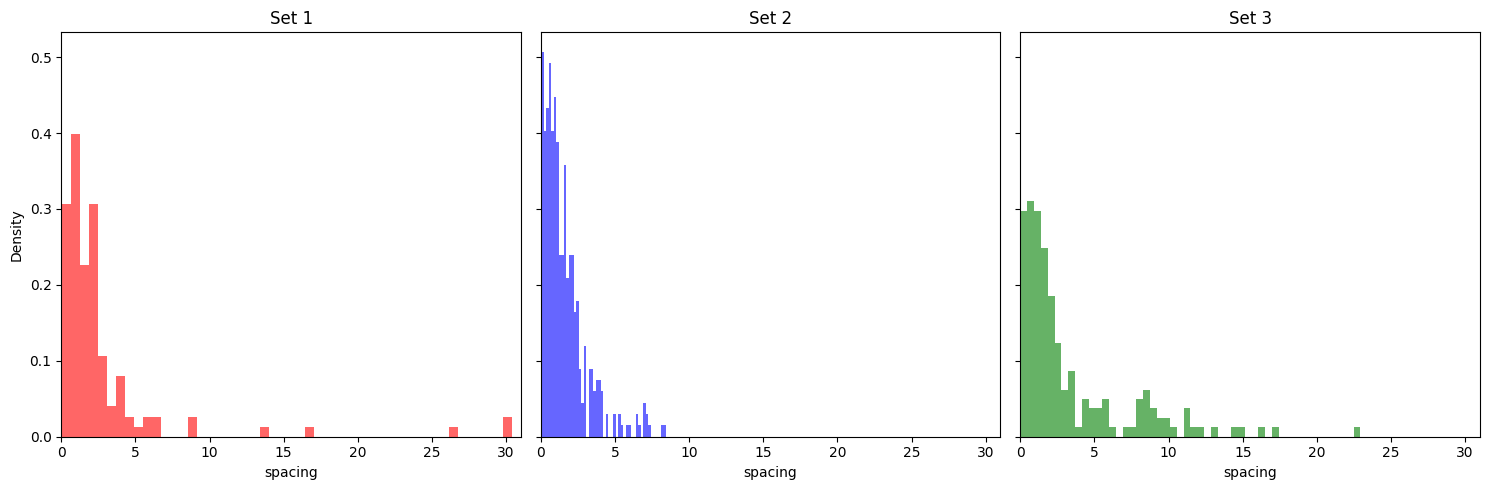

In [40]:
plot_spacing_distribution(results_df, num_sets)